
--- Evaluating Density Level: 1.00% ---
Density 1.00%: Average Lanczos basis size = 246.90 Average Runtime 0.6265

--- Evaluating Density Level: 5.00% ---
Density 5.00%: Average Lanczos basis size = 244.70 Average Runtime 1.1065

--- Evaluating Density Level: 10.00% ---
Density 10.00%: Average Lanczos basis size = 269.48 Average Runtime 2.1689

--- Evaluating Density Level: 15.00% ---
Density 15.00%: Average Lanczos basis size = 285.62 Average Runtime 2.9798

--- Evaluating Density Level: 20.00% ---
Density 20.00%: Average Lanczos basis size = 260.35 Average Runtime 3.3901

--- Evaluating Density Level: 25.00% ---
Density 25.00%: Average Lanczos basis size = 320.00 Average Runtime 4.6145

--- Evaluating Density Level: 30.00% ---
Density 30.00%: Average Lanczos basis size = 265.43 Average Runtime 4.2291

--- Evaluating Density Level: 35.00% ---
Density 35.00%: Average Lanczos basis size = 257.82 Average Runtime 4.6112

--- Evaluating Density Level: 40.00% ---
Density 40.00%: Average La

ValueError: x and y must have same first dimension, but have shapes (21,) and (1,)

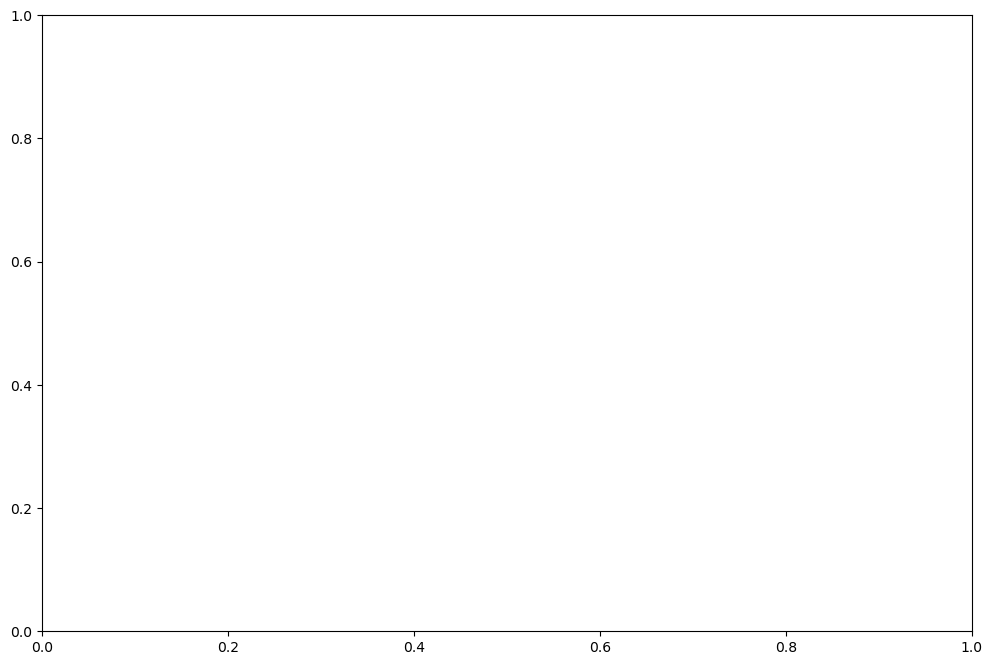

In [1]:
import numpy as np
from scipy.sparse import random as sparse_random, csr_matrix
import matplotlib.pyplot as plt
import numba as nb
from scipy.sparse.linalg import eigsh
import time

# Matrix Generation
def generate_sparse_matrix(size, density):
    diagonal = np.linspace(-1, 1, size)
    # Use a random generator for nonzero off-diagonals.
    rvs = np.random.randn
    # Build upper triangle with density/2 so that overall density is ~density.
    upper = sparse_random(size, size, density=density/2, data_rvs=rvs, format='coo')
    A = upper + upper.T
    A.setdiag(diagonal)
    return A.tocsr()

# Block CSR Matrix-Vector Multiplication (Numba Accelerated)
@nb.njit(parallel=True, fastmath=True, cache=True)
def block_csr_mv(A_data, A_indices, A_indptr, X):
    n = A_indptr.shape[0] - 1
    b = X.shape[1]
    Y = np.zeros((n, b), dtype=X.dtype)
    for i in nb.prange(n):
        for j in range(A_indptr[i], A_indptr[i+1]):
            col = A_indices[j]
            for k in range(b):
                Y[i, k] += A_data[j] * X[col, k]
    return Y

@nb.njit(fastmath=True, cache=True)
def block_lanczos_loop(A_data, A_indices, A_indptr, Q, T_blocks, m, b, ortho_thresh):
    n = Q.shape[0]
    eps = np.finfo(np.float64).eps
    m_eff = m  # effective number of block iterations
    for k in range(m):
        # Indices of block k.
        start = k * b
        end = (k+1) * b
        Qk = Q[:, start:end]
        # Compute new block: V = A * Qk.
        V = block_csr_mv(A_data, A_indices, A_indptr, Qk)
        # Compute block alpha = Qk^T V, (b,b) matrix.
        Qk_contig = np.ascontiguousarray(Qk)
        V_contig = np.ascontiguousarray(V)
        alpha = np.dot(Qk_contig.T, V_contig)
        # Store alpha in diagonal block T_blocks[k,k].
        for i in range(b):
            for j in range(b):
                T_blocks[k, k, i, j] = alpha[i, j]
        # Subtract Qk * alpha from V.
        Qk_contig = np.ascontiguousarray(Qk)
        alpha_contig = np.ascontiguousarray(alpha)
        V = V - np.dot(Qk_contig, alpha_contig)
        # If k > 0, subtract contribution from previous block.
        if k > 0:
            Q_prev = Q[:, (k-1)*b : k*b]
            beta_prev = T_blocks[k, k-1]  # (b,b) block
            Qk_contig = np.ascontiguousarray(Q_prev)
            beta_contig = np.ascontiguousarray(beta_prev)
            V = V - np.dot(Qk_contig, beta_contig)
        # Compute Frobenius norm of V.
        norm_V = np.sqrt(np.sum(V * V))
        dyn_thresh = max(ortho_thresh, np.sqrt(eps) * norm_V)
        for rep in range(2):  # perform two passes
            for j in range(k+1):
                Qj = Q[:, j*b:(j+1)*b]
                Qj_contig = np.ascontiguousarray(Qj)
                V_contig = np.ascontiguousarray(V)
                P = np.dot(Qj_contig.T, V_contig)
                # Manual Frobenius norm:
                proj_norm = np.sqrt(np.sum(P * P))
                if proj_norm > dyn_thresh:
                    V = V - np.dot(Qj_contig, P)
        Q_new, R = np.linalg.qr(V)  # Q_new (n, b), R (b,b)
        # Store Q_new into next block of Q.
        next_start = (k+1)*b
        next_end = (k+2)*b
        Q[:, next_start:next_end] = Q_new
        # Store R as off-diagonal block beta.
        T_blocks[k+1, k] = R
        T_blocks[k, k+1] = R.T
        # Test for breakdown.
        rnorm = np.sqrt(np.sum(R * R))
        if rnorm == 0:
            m_eff = k + 1
            return m_eff
    return m_eff

#Implicit Restarted Lanczos (IRL) with Deflation and Shift Selection
def block_irl(matrix_s, v_init, tol=1e-8, m=None, max_iter=40000, max_m=100, ortho_thresh=1e-10, k=1):
    n = matrix_s.shape[0]
    # Set default m if not provided.
    if m is None:
        m = max(2*k+1, 40)
    # Allocate Q to hold (m+1) blocks (each block of size k): shape (n, (m+1)*k).
    Q = np.zeros((n, (m+1)*k), dtype=np.float64)
    # T_blocks is of shape (m+1, m, k, k).
    T_blocks = np.zeros((m+1, m, k, k), dtype=np.float64)
    # Ensure initial block v_init is of shape (n, k).
    if v_init.ndim == 1:
        v_init = v_init.reshape(-1, 1)
        if k > 1:
            v_init = np.repeat(v_init, k, axis=1)
    # Normalize the initial block using the Frobenius norm.
    norm_init = np.sqrt(np.sum(v_init*v_init))
    Q[:, :k] = v_init / norm_init
    A = matrix_s.tocsr()
    A_data = A.data
    A_indices = A.indices
    A_indptr = A.indptr
    total_iters = 0
    instantaneous_sizes = []  # record number of individual Lanczos vectors per restart cycle
    restart_count = 0
    last_ritz_res = np.inf
    # We'll keep track of locked (converged) eigenpairs.
    locked = np.zeros(k, dtype=bool)
    # Main restart loop.
    while total_iters < max_iter:
        # Run a block Lanczos cycle.
        m_eff = block_lanczos_loop(A_data, A_indices, A_indptr, Q, T_blocks, m, k, ortho_thresh)
        total_iters += m_eff
        instantaneous_sizes.append(m_eff * k)
        # Assemble the small block tridiagonal matrix T_dense.
        T_dense = np.zeros((m_eff*k, m_eff*k), dtype=np.float64)
        for i in range(m_eff):
            # Diagonal block.
            T_dense[i*k:(i+1)*k, i*k:(i+1)*k] = T_blocks[i, i] if i < m_eff else np.zeros((k, k))
            if i < m_eff - 1:
                T_dense[(i+1)*k:(i+2)*k, i*k:(i+1)*k] = T_blocks[i+1, i]
                T_dense[i*k:(i+1)*k, (i+1)*k:(i+2)*k] = T_blocks[i+1, i].T
        # Compute Ritz pairs (eigenpairs of T_dense).
        eigvals, eigvecs = np.linalg.eigh(T_dense)
        # Estimate residuals for each Ritz pair.
        residuals = np.zeros(eigvals.shape)
        for j in range(eigvals.shape[0]):
            # A crude estimate: the last block row’s average magnitude times the maximum entry of the Ritz vector.
            residuals[j] = np.abs(T_dense[-1, -k:]).mean() * np.abs(eigvecs[-k:, j]).max()
        # Lock converged Ritz pairs (deflation).
        for j in range(eigvals.shape[0]):
            if residuals[j] < tol * max(1.0, abs(eigvals[j])):
                locked[j % k] = True   # Here we simply mark (mod k) as locked.
        if np.sum(locked) >= k:
            # Convergence achieved for all desired eigenpairs.
            # Map the k Ritz vectors (corresponding to the smallest k eigenvalues) back to the original space.
            approx_eigvecs = Q[:, :m_eff*k] @ eigvecs[:, :k]
            return total_iters, eigvals[:k], approx_eigvecs, instantaneous_sizes
        # Advanced Shift Selection
        # For simplicity, target the smallest eigenvalue.
        target_ind = np.argmin(eigvals)
        target_val = eigvals[target_ind]
        # Unwanted shifts: all eigenvalues except the target.
        unwanted = np.delete(eigvals, target_ind)
        unwanted_shifts = np.sort(unwanted)[::-1]
        refined_shifts = []
        for mu in unwanted_shifts:
            if abs(mu - target_val) > tol * max(1.0, abs(target_val)):
                refined_shifts.append(mu)
        refined_shifts = np.array(refined_shifts)
        # Implicit Restart via Block QR Filtering
        # Apply sequential block QR filtering on T_dense.
        V_plus = np.eye(m_eff*k)
        T_temp = T_dense.copy()
        for mu in refined_shifts:
            Q_shift, R_shift = np.linalg.qr(T_temp - mu * np.eye(m_eff*k))
            T_temp = R_shift @ Q_shift + mu * np.eye(m_eff*k)
            V_plus = V_plus @ Q_shift
        # Form new starting block from Q and V_plus.
        new_block = Q[:, :m_eff*k] @ V_plus[:, :k]
        # Re-orthonormalize the new block.
        Q_new, _ = np.linalg.qr(new_block)
        Q[:, :k] = Q_new
        # Adaptive Restart: if progress stalls, increase m.
        if np.mean(residuals) > 0.8 * last_ritz_res and m < max_m:
            new_m = min(int(m * 1.15), max_m)
            m = new_m
            new_Q = np.zeros((n, (m+1)*k), dtype=np.float64)
            new_Q[:, :k] = Q_new  # carry over new starting block.
            Q = new_Q
            T_blocks = np.zeros((m+1, m, k, k), dtype=np.float64)
        last_ritz_res = np.mean(residuals)
        restart_count += 1
    # If max_iter is reached without full convergence.
    approx_eigvecs = Q[:, :m_eff*k] @ eigvecs[:, :k]
    return total_iters, eigvals[:k], approx_eigvecs, instantaneous_sizes


def evaluate_block_basis_sizes(size, density_levels, num_trials=40, tol=1e-8, max_iter=40000, ortho_thresh=1e-10, k=1):
    total_basis_sizes = {}
    runtime_dict = {}
    for density in density_levels:
        print(f"\n--- Evaluating Density Level: {density*100:.2f}% ---", flush=True)
        trial_basis_sizes = []
        trial_runtimes = []
        for trial in range(num_trials):
            A = generate_sparse_matrix(size, density)
            start_time = time.time()
            # Use a random initial block of shape (n, k)
            v_init = np.random.rand(size, k)
            _, _, _, inst_sizes = block_irl(A, v_init, tol=tol, m=None, max_iter=max_iter, max_m=100, ortho_thresh=ortho_thresh, k=k)
            runtime = time.time() - start_time
            total_trial_basis = np.sum(inst_sizes)
            trial_basis_sizes.append(total_trial_basis)
            trial_runtimes.append(runtime)
        total_basis_sizes[density] = trial_basis_sizes
        runtime_dict[density] = trial_runtimes
        avg_basis = np.mean(trial_basis_sizes)
        avg_runtime = np.mean(trial_runtimes)
        print(f"Density {density*100:.2f}%: Average Lanczos basis size = {avg_basis:.2f} Average Runtime {avg_runtime:.4f}")
    return total_basis_sizes, runtime_dict

size = 10000
density_levels = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]
k = 1  # number of eigenpairs (and block size)
avg_total_sizes, avg_runtime = evaluate_block_basis_sizes(size, density_levels, num_trials=40, tol=1e-8, max_iter=40000, ortho_thresh=1e-10, k=k)

#density vs average lanczos basis size
plt.figure(figsize=(12, 8))
plt.plot(density_levels, avg_total_sizes, marker='o', linestyle='-', color='b')
plt.xlabel('Density Level')
plt.ylabel('Average Lanczos Basis Size')
plt.title('Density vs. Average Lanczos Basis Size')
plt.grid(True)
plt.show()

